In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cme.utils.post_process_model as ut
import glob as gl

In [2]:
datasets = [
            "Single Stage - Fast RT",
            "Single Stage - Slow RT",              
            #"rpm"
            ]
model = "Quantum"
version = 0.2
file_pre="data/sim_"
sample_size=20
file_post_ra="_" + str(sample_size)  + "_ra.csv"
file_post_rt="_" + str(sample_size)  + "_rt.csv"
header=None

def get_dataframes(file_pre, file_post, file_list, size, version="", batch_size=0, header=None, is_glob=False):
    if not is_glob: 
        return pd.concat([pd.read_csv(f"{file_pre}{d}{file_post}",header=header).assign(dataset=d,size=size).reset_index(names="id") for d in file_list]).reset_index(drop=True)
    else:
        return pd.concat(
            [
                pd.read_csv(f"{f}",header=header)
                  .assign(size=size, subfile_id = f.split(str(version)+"_")[1].removesuffix(".csv"))  
                  .assign(dataset=d)
                  #.assign(dims = lambda df:df.params.str.split("[", expand=True)[1].str.removesuffix("]")) 
                  #.sort_values(["subfile_id", "part_id", "items"])
                  .assign(id = lambda df: df.part_id.astype(int) + (df.subfile_id.astype(int) * (batch_size)))
                  .reset_index(drop=True) 
                for d in file_list
                for f in gl.glob(file_pre + d + file_post + "_*.csv") 
            ]).reset_index(drop=True)

# Data used to fit the model

## Response Time

In [3]:
df_observed_rt = ut.collect_dataframes(file_pre, file_post_rt, datasets, sample_size, header=None).reset_index(names="id")
df_observed_rt

,id,0,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,28,29,dataset,size
0,0,3.330432,3.560432,3.310432,3.140432,3.080432,3.230432,2.750432,2.570432,3.360432,...,2.620432,4.190432,2.820432,3.530432,3.000432,3.740432,2.340432,2.230432,Single Stage - Fast RT,20
1,1,2.040432,2.550432,2.880432,3.600432,1.990432,3.820432,1.730432,2.450432,3.540432,...,2.180432,2.000432,2.220432,2.670432,4.020432,3.290432,2.240432,2.390432,Single Stage - Fast RT,20
2,2,3.160432,3.560432,2.440432,2.200432,2.460432,2.160432,2.650432,3.700432,3.560432,...,4.060432,3.530432,3.000432,2.350432,1.890432,2.910432,3.440432,2.470432,Single Stage - Fast RT,20
3,3,2.910432,2.920432,1.930432,3.860432,3.060432,2.990432,2.200432,1.960432,2.620432,...,4.000432,3.200432,2.080432,2.280432,2.810432,3.090432,2.950432,3.150432,Single Stage - Fast RT,20
4,4,3.880432,3.390432,3.730432,3.730432,2.980432,2.390432,4.140432,2.450432,2.240432,...,2.860432,3.610432,4.290432,2.920432,2.960432,3.670432,3.450432,3.120432,Single Stage - Fast RT,20
5,5,4.040432,2.960432,2.200432,2.980432,2.330432,2.940432,3.010432,2.260432,3.460432,...,2.580432,4.560432,3.540432,2.290432,3.230432,2.760432,3.840432,3.190432,Single Stage - Fast RT,20
6,6,3.360432,2.290432,1.910432,2.210432,3.400432,4.000432,3.380432,2.220432,3.390432,...,2.700432,3.900432,3.410432,3.430432,3.670432,3.470432,2.390432,3.570432,Single Stage - Fast RT,20
7,7,1.940432,2.180432,2.660432,2.260432,3.030432,4.310432,3.760432,3.890432,2.680432,...,3.600432,2.830432,2.380432,4.240432,3.110432,2.580432,2.240432,2.650432,Single Stage - Fast RT,20
8,8,2.910432,3.130432,2.360432,3.810432,4.180432,2.810432,3.440432,3.990432,3.060432,...,3.180432,2.770432,1.920432,3.620432,3.960432,3.180432,3.010432,3.410432,Single Stage - Fast RT,20
9,9,3.180432,3.100432,3.290432,3.090432,3.310432,3.380432,2.410432,2.410432,2.830432,...,3.650432,3.060432,2.750432,3.330432,2.690432,2.060432,2.720432,3.640432,Single Stage - Fast RT,20


2024-07-09 07:45:49,122 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2024-07-09 07:45:49,123 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2024-07-09 07:45:49,123 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2024-07-09 07:45:49,123 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansDisplay.ttf', na

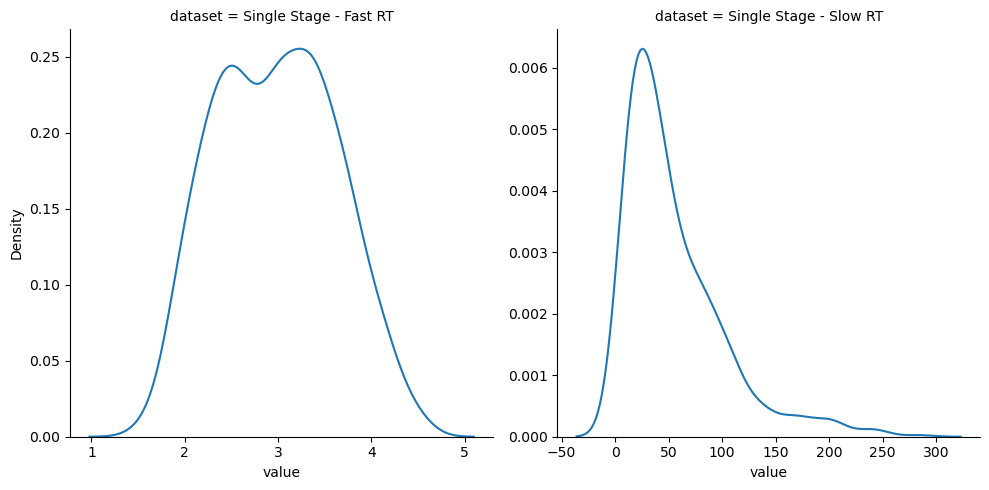

In [4]:
sns.displot(df_observed_rt.melt(id_vars=["dataset", "size", "id"]),
x="value",
col="dataset",kind="kde", facet_kws=dict(sharex=False,sharey=False))

In [5]:
df_observed_ra = ut.collect_dataframes(file_pre, file_post_ra, datasets,sample_size,header=None).reset_index(names="id")
df_observed_ra

,id,0,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,28,29,dataset,size
0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
2,2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
3,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
4,4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
5,5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
6,6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
7,7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
8,8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20
9,9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Single Stage - Fast RT,20


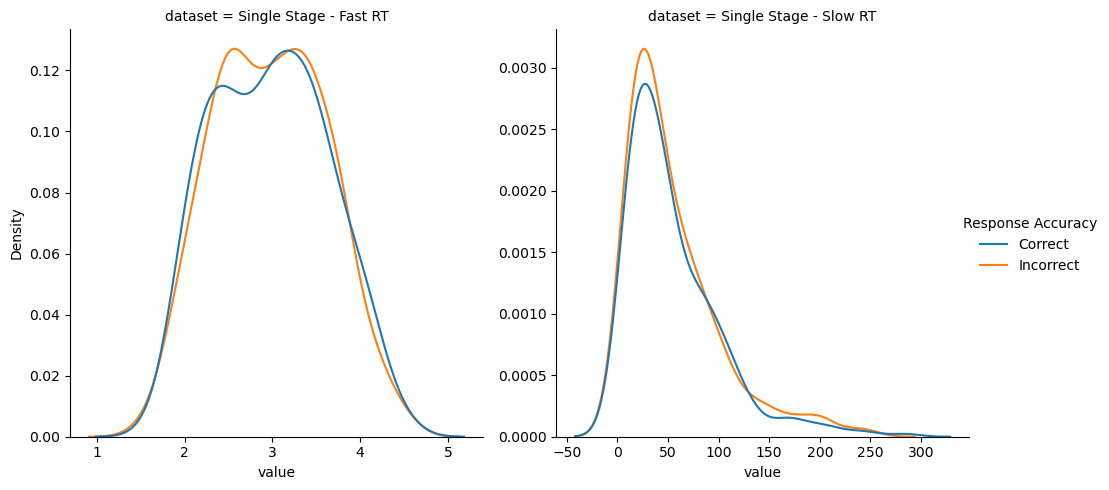

In [6]:
f = sns.displot(df_observed_rt.melt(id_vars=["dataset", "size", "id"]).join(df_observed_ra.melt(id_vars=["dataset", "size", "id"]).assign(value = lambda df: df.value.map({0:"Incorrect",1:"Correct"})),rsuffix="_ra"),
x="value",
hue="value_ra",
col="dataset", kind="kde", facet_kws={"sharex":False, "sharey":False})
f.legend.set_title("Response Accuracy")

# Prior Predictive Distribution
## Response Time

In [11]:
file_pre = "export/" + "prior_predictive_sim_" 
file_list = [datasets[0]]

file_post_pred = "_"+str(sample_size) #+ "_" + model #+ "_" + str(version)
df_prior_pred = ut.collect_dataframes(file_pre, file_post_pred, datasets, sample_size, version=version, model=model, batch_size=10, header="infer", is_glob=True)
df_prior_pred

2024-07-09 07:48:00,160 - root - INFO - Getting files from export/prior_predictive_sim_*_20_Quantum_0.2_*.csv


,part_id,items,RT,logp,param_sample_id,weighted_sample,size,subfile_id,dataset,id
0,0,22,2.620432,0.024535,0,0,20,0,Single Stage - Fast RT,0
1,0,12,2.510432,0.024535,0,0,20,0,Single Stage - Fast RT,0
2,0,5,3.230432,0.022365,0,0,20,0,Single Stage - Fast RT,0
3,0,14,2.440432,0.024535,0,0,20,0,Single Stage - Fast RT,0
4,0,29,2.230432,0.024535,0,0,20,0,Single Stage - Fast RT,0
...,...,...,...,...,...,...,...,...,...,...
59995,19,2,12.089268,0.003251,49,0,20,0,Single Stage - Slow RT,19
59996,19,0,45.209268,0.001749,49,0,20,0,Single Stage - Slow RT,19
59997,19,17,4.989268,0.013581,49,0,20,0,Single Stage - Slow RT,19
59998,19,1,47.389268,0.000780,49,0,20,0,Single Stage - Slow RT,19


#size=sample_size
#df_pred = df_prior_pred
#df_rt = df_observed_rt
#ncols=2
#nrows=1

def get_predictive_plot(df_pred, df_rt, size, ncols, nrows, type="Prior|Posterior"):

    fig, axs = plt.subplots(ncols = ncols, nrows=nrows, figsize=(12,5))

    #df_pred = df_pred.assign(RT = lambda df: np.exp(df.RT))

    for (k, df), ax in zip(df_pred.query(f"size=={size}").groupby(["dataset"]),axs.flatten()):
        print(k)
        RT_p = df_rt.query(f"dataset == '{k[0]}' and size=={size}").drop(["dataset", "size", "id"], axis=1).to_numpy().flatten()
        #RT_p = np.exp(RT_p)
        sns.kdeplot(df.query(f"size=={size}"), x="RT", hue="param_sample_id", common_norm=False, legend=False, palette=["blue"], alpha=0.02, ax=ax)
        ax.axvline(np.median(df.query(f"size=={size}")["RT"]), color = "blue", label="Posterior Predicted")
        sns.kdeplot(RT_p, color="black", linewidth=3, ax=ax)
        ax.axvline(np.median(RT_p), color="black", label = "DGP(Observed)")
        #ax.set_title(s + " participants")
        ax.set_title(k[0])
        ax.set_xlabel("Response Time (secs)")
        ax.set_ylabel("")
    plt.suptitle(f"{type} Predicted vs DGP(observed) Response Time Distributions")
    plt.tight_layout()
    plt.legend()


('Single Stage - Fast RT',)
('Single Stage - Slow RT',)


/home/axon/rkm160630/ritesh/computational_models_of_reasoning/cme/utils/post_process_model.py:83: UserWarning: 
The palette list has fewer values (1) than needed (50) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(df, x="RT", hue="param_sample_id", common_norm=False, legend=False, palette=["blue"], alpha=0.02, ax=ax)
/home/axon/rkm160630/ritesh/computational_models_of_reasoning/cme/utils/post_process_model.py:83: UserWarning: 
The palette list has fewer values (1) than needed (50) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(df, x="RT", hue="param_sample_id", common_norm=False, legend=False, palette=["blue"], alpha=0.02, ax=ax)


2024-07-09 07:48:43,887 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2024-07-09 07:48:43,888 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2024-07-09 07:48:43,888 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2024-07-09 07:48:43,888 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansDisplay.ttf', na

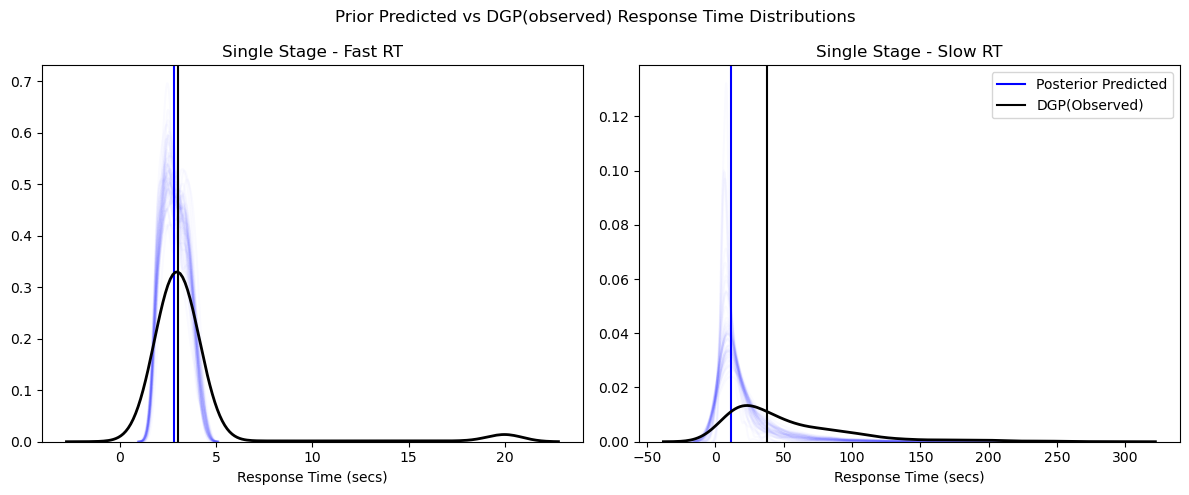

In [13]:
ut.get_predictive_plot(df_prior_pred, df_observed_rt, 2, 1, "Prior")

# Model Convergence

In [14]:
file_pre = "export/" + "posterior_summary_sim_" 
file_list = [datasets[0]]

file_post_pred = "_"+str(sample_size) #+ "_" + model + "_" + str(version)
df_summ = ut.collect_dataframes(file_pre, file_post_pred, datasets, sample_size, version=version, model=model, batch_size=10, header="infer", is_glob=True)
df_summ = df_summ.assign(dims = lambda df:df.params.str.split("[", expand=True)[1].str.removesuffix("]")) 
df_summ
#.params.str.split("[",expand=True)[1].str.split(",",expand=True)[0]

2024-07-09 07:49:10,882 - root - INFO - Getting files from export/posterior_summary_sim_*_20_Quantum_0.2_*.csv


,Unnamed: 0,params,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,param_name,part_id,dims,size,subfile_id,dataset,id
0,0,"mu[0, 0]",0.344,0.470,-0.680,1.045,0.040,0.028,226.0,156.0,1.02,mu,0,"0, 0",20,0,Single Stage - Fast RT,0
1,1,"mu[1, 0]",0.378,0.487,-0.784,1.114,0.073,0.052,83.0,51.0,1.04,mu,1,"1, 0",20,0,Single Stage - Fast RT,1
2,2,"mu[2, 0]",0.433,0.401,-0.369,1.097,0.025,0.018,124.0,502.0,1.03,mu,2,"2, 0",20,0,Single Stage - Fast RT,2
3,3,"mu[3, 0]",0.412,0.442,-0.554,1.081,0.021,0.015,287.0,1000.0,1.02,mu,3,"3, 0",20,0,Single Stage - Fast RT,3
4,4,"mu[4, 0]",0.433,0.394,-0.269,1.138,0.018,0.013,379.0,360.0,1.01,mu,4,"4, 0",20,0,Single Stage - Fast RT,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1675,835,"likl_rt[19, 25]",0.000,0.001,0.000,0.002,0.000,0.000,2706.0,5140.0,1.00,likl_rt,19,"19, 25",20,0,Single Stage - Slow RT,19
1676,836,"likl_rt[19, 26]",0.001,0.001,0.000,0.003,0.000,0.000,4699.0,4483.0,1.00,likl_rt,19,"19, 26",20,0,Single Stage - Slow RT,19
1677,837,"likl_rt[19, 27]",0.005,0.006,0.000,0.017,0.000,0.000,1985.0,2724.0,1.00,likl_rt,19,"19, 27",20,0,Single Stage - Slow RT,19
1678,838,"likl_rt[19, 28]",0.000,0.000,0.000,0.001,0.000,0.000,2625.0,5233.0,1.00,likl_rt,19,"19, 28",20,0,Single Stage - Slow RT,19


<Axes: ylabel='Frequency'>

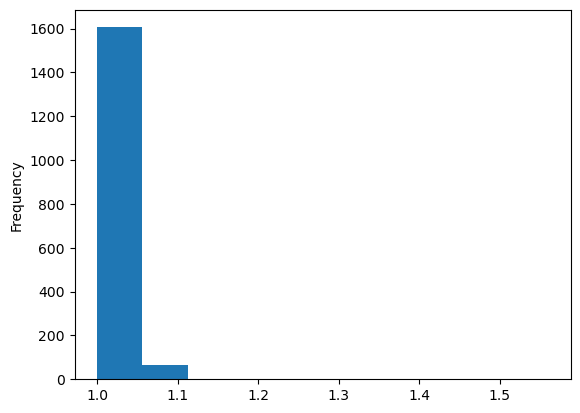

In [15]:
df_summ.r_hat.plot.hist()

## Drift Rate

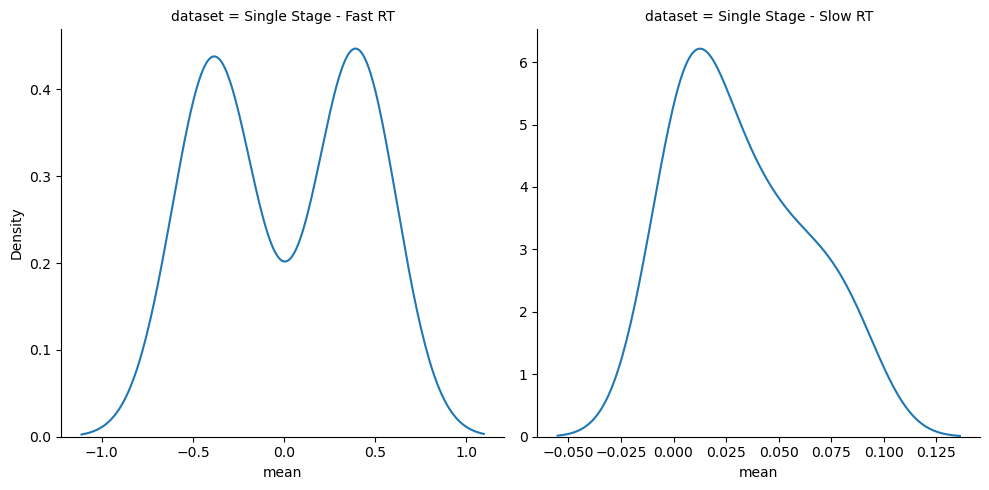

In [16]:
df_v = df_summ.query("param_name == 'mu'")[["mean", "id", "dataset", "size"]]
sns.displot(df_v,
x="mean", col="dataset", kind="kde", facet_kws = dict(sharex=False, sharey=False)
)

df_summ.query("param_name == 'phi_0'").assign(item = lambda df:df.dims.str.split(",",expand=True)[1],
                                              state = lambda df:df.dims.str.split(",",expand=True)[2]
)[["mean", "id", "item", "state", "dataset", "size"]].pivot(index=["id", "item",  "dataset", "size"], columns="state", values = "mean")

#[["mean", "id", "dataset", "size"]]
# get item id from params to make this plot

# Posterior Predictive Check

In [18]:
file_pre = "export/" + "posterior_predictive_sim_" 
file_list = [datasets[0]]

file_post_pred = "_"+str(sample_size)# + "_" + model + "_" + str(version)
df_post_pred = ut.collect_dataframes(file_pre, file_post_pred, datasets, sample_size, model=model, version=version, batch_size=10, header="infer", is_glob=True)
df_post_pred

2024-07-09 07:49:35,420 - root - INFO - Getting files from export/posterior_predictive_sim_*_20_Quantum_0.2_*.csv


,part_id,items,RT,logp,param_sample_id,weighted_sample,size,subfile_id,dataset,id
0,0,18,2.680432,0.014841,0,0,20,0,Single Stage - Fast RT,0
1,0,28,2.340432,0.012616,0,0,20,0,Single Stage - Fast RT,0
2,0,16,2.920432,0.014967,0,0,20,0,Single Stage - Fast RT,0
3,0,26,3.000432,0.014543,0,0,20,0,Single Stage - Fast RT,0
4,0,16,2.920432,0.014967,0,0,20,0,Single Stage - Fast RT,0
...,...,...,...,...,...,...,...,...,...,...
59995,19,19,4.879268,0.000464,49,0,20,0,Single Stage - Slow RT,19
59996,19,27,10.309268,0.000544,49,0,20,0,Single Stage - Slow RT,19
59997,19,7,12.519268,0.000413,49,0,20,0,Single Stage - Slow RT,19
59998,19,19,4.879268,0.000464,49,0,20,0,Single Stage - Slow RT,19


('Single Stage - Fast RT',)
('Single Stage - Slow RT',)


/home/axon/rkm160630/ritesh/computational_models_of_reasoning/cme/utils/post_process_model.py:83: UserWarning: 
The palette list has fewer values (1) than needed (50) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(df, x="RT", hue="param_sample_id", common_norm=False, legend=False, palette=["blue"], alpha=0.02, ax=ax)
/home/axon/rkm160630/ritesh/computational_models_of_reasoning/cme/utils/post_process_model.py:83: UserWarning: 
The palette list has fewer values (1) than needed (50) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(df, x="RT", hue="param_sample_id", common_norm=False, legend=False, palette=["blue"], alpha=0.02, ax=ax)


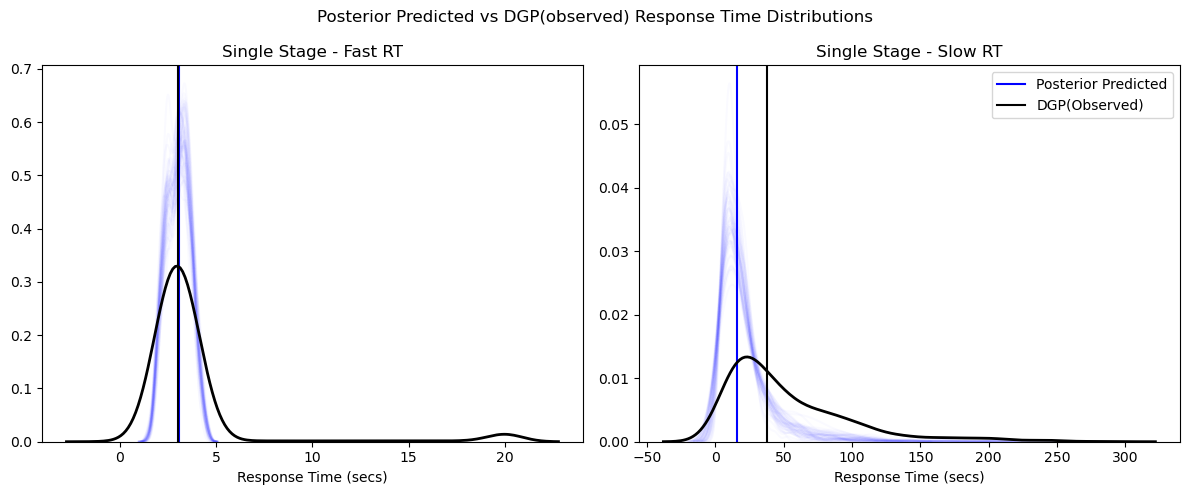

In [19]:
ut.get_predictive_plot(df_post_pred, df_observed_rt, 2, 1, "Posterior")